### Imports and Data Loading

In [1]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp

In [2]:
BASE_PATH = r"C:\Users\mills\Desktop\Angione Lab\OC"

adata = sc.read_h5ad(os.path.join(BASE_PATH, "adata_with_clusters.h5ad"))

print(adata)
print(adata.obs.columns)

AnnData object with n_obs × n_vars = 63072 × 150
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'outlier', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_Gene', 'leiden_CNN', 'leiden_Multimodal', 'tmp_leiden_Gene_0', 'tmp_leiden_Gene_1', 'tmp_leiden_Gene_2', 'tmp_leiden_Gene_3', 'tmp_leiden_Gene_4', 'tmp_leiden_CNN_0', 'tmp_leiden_CNN_1', 'tmp_leiden_CNN_2', 'tmp_leiden_CNN_3', 'tmp_leiden_CNN_4', 'tmp_leiden_Multimodal_0', 'tmp_leiden_Multimodal_1', 'tmp_leiden_Multimodal_2', 'tmp_leiden_Multimodal_3', 'tmp_leiden_Multimodal_4', 'leiden_CNN_top'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 

### Differential Gene Expression (Marker Identification)

In [3]:
CLUSTER_KEY = "leiden"

In [4]:
sc.tl.rank_genes_groups(
    adata,
    groupby=CLUSTER_KEY,
    method="wilcoxon",
    pts=True
)

C:\Users\mills\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\mills\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\mills\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\mills\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\mills\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\scanpy\tools\_rank_genes

### Marker Gene Visualization

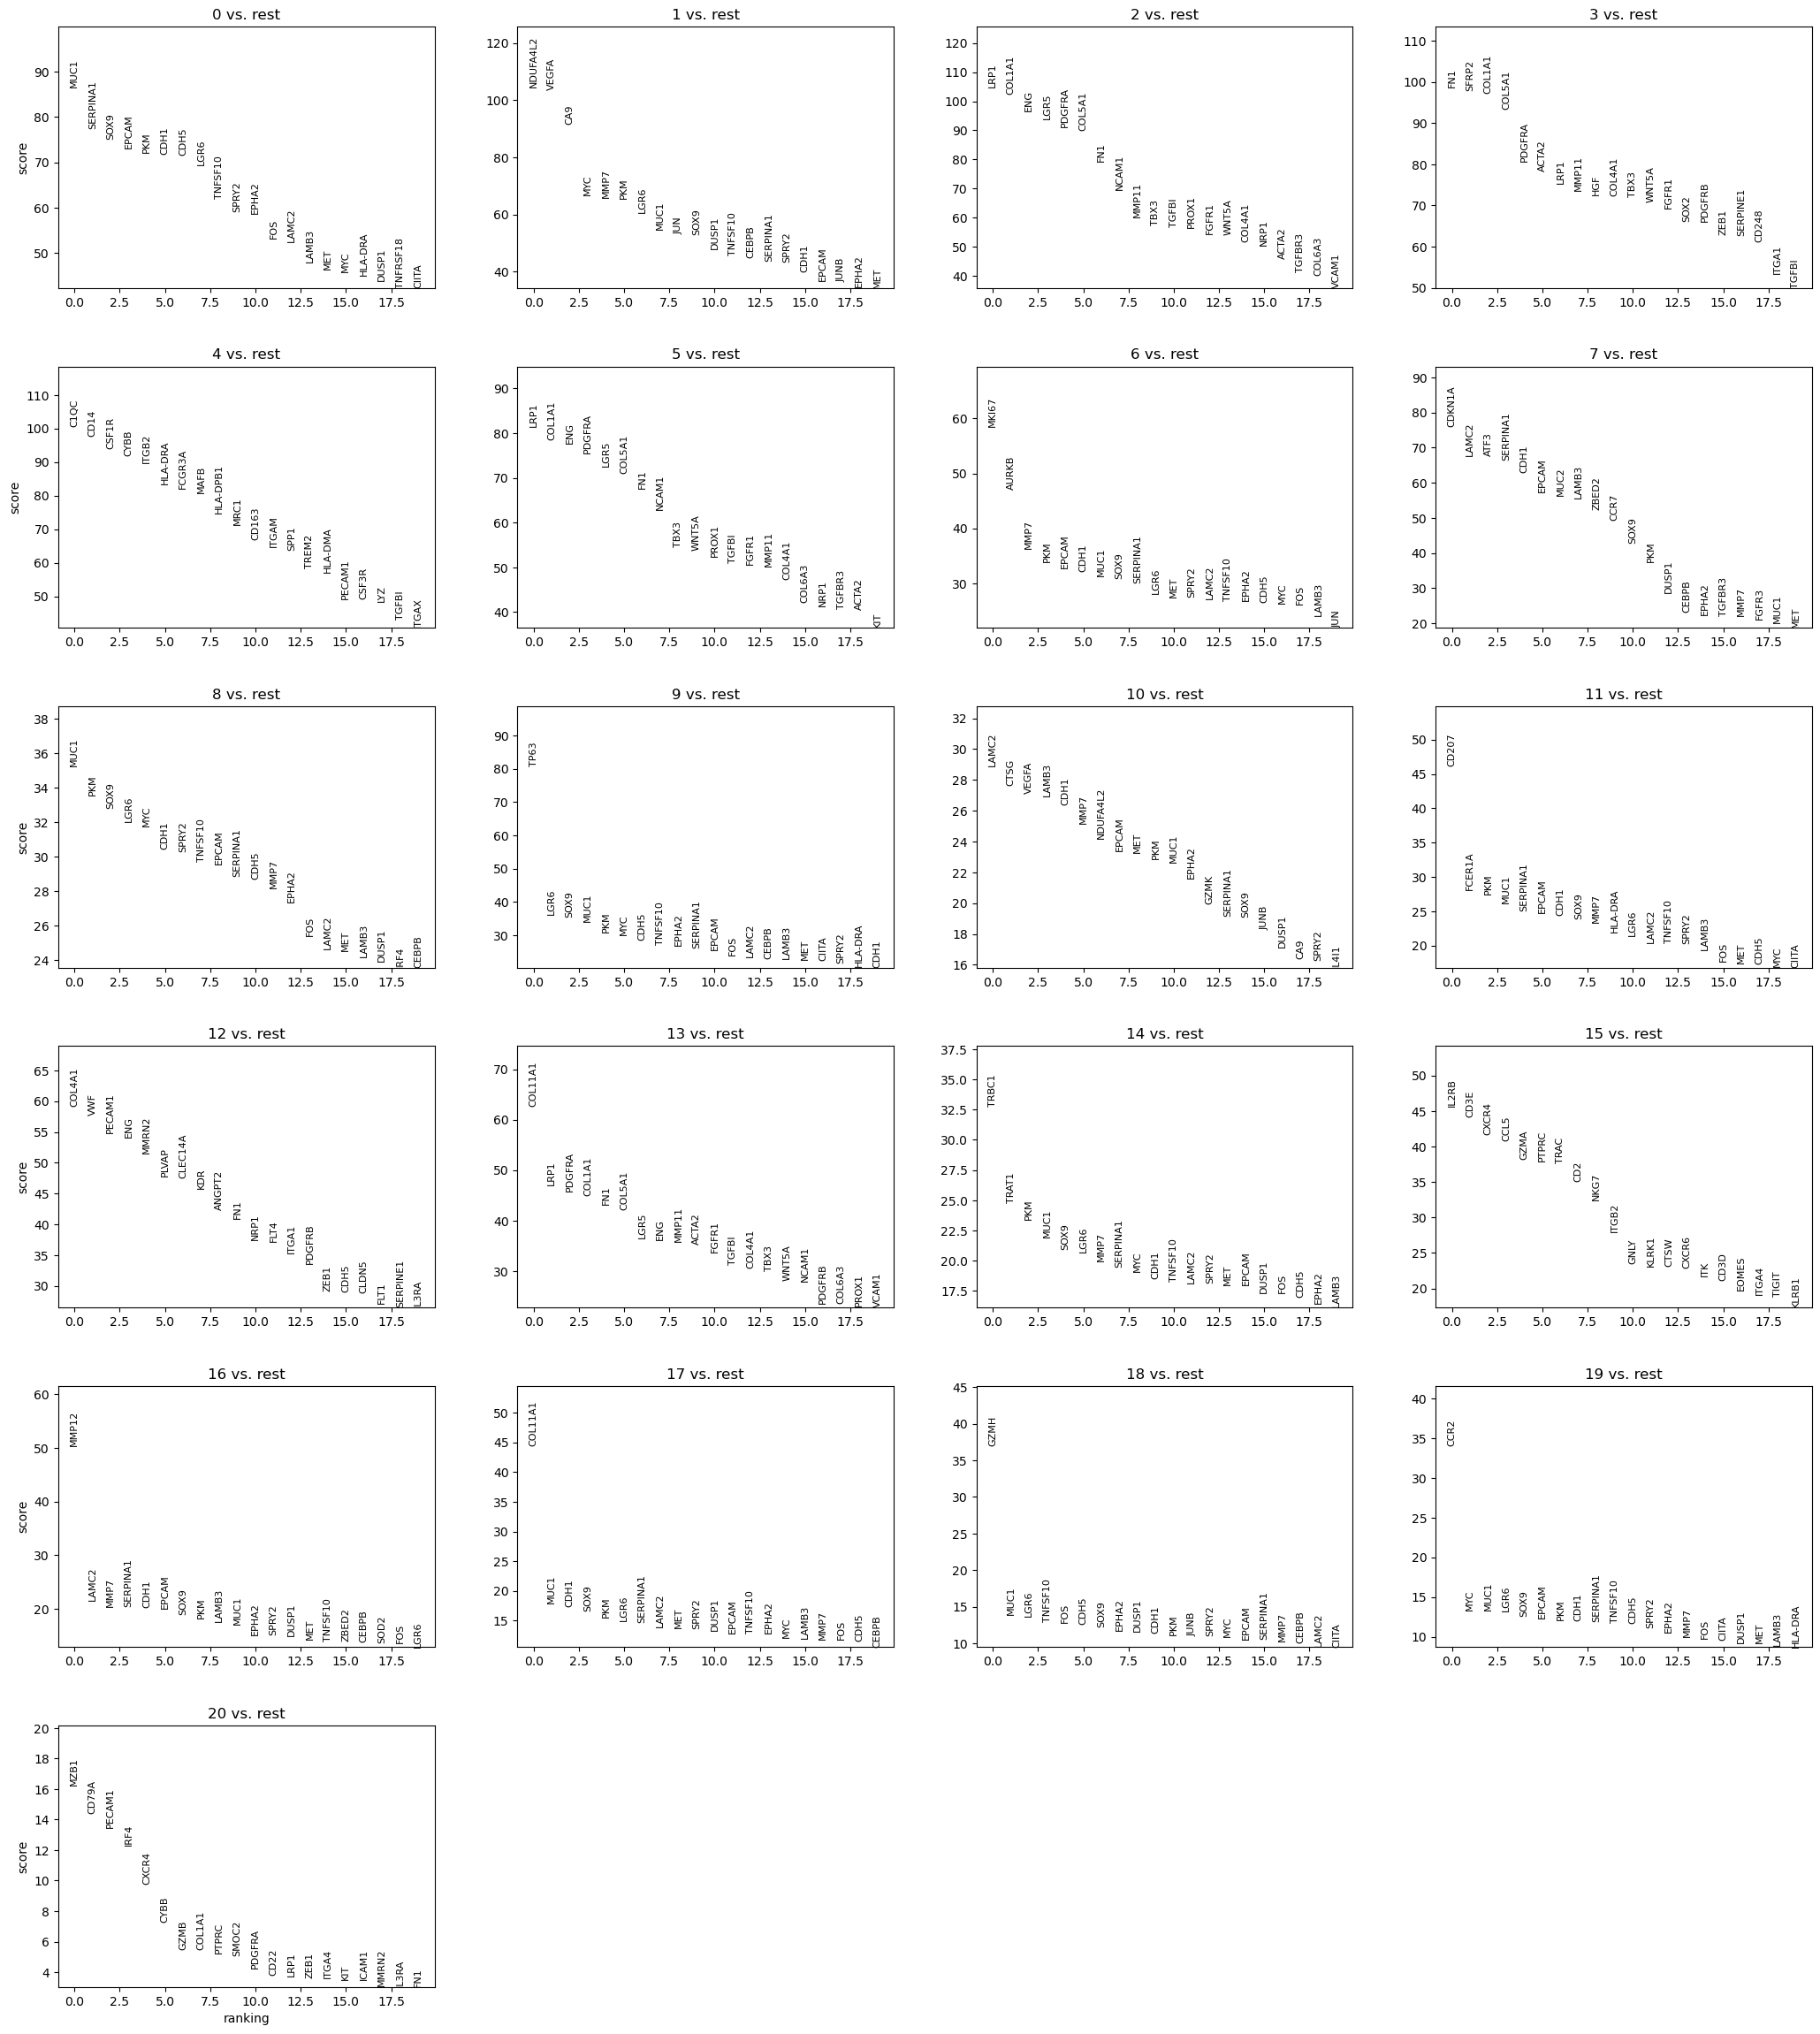

In [23]:
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

### Marker Gene Filtering

In [27]:
def get_filtered_genes(adata, cluster, top_n=50):
    df = sc.get.rank_genes_groups_df(adata, group=cluster)

    df = df[
        (df["pvals_adj"] < 0.05) &
        (df["logfoldchanges"] > 0.25)
    ].sort_values("logfoldchanges", ascending=False)

    if df.shape[0] < 10:
        df = sc.get.rank_genes_groups_df(adata, group=cluster)
        df = df.sort_values("logfoldchanges", ascending=False)

    return df.head(top_n)

### Functional Enrichment Analysis

In [6]:
background_genes = adata.var_names.tolist()

def run_enrichment(gene_list):
    if len(gene_list) < 5:
        return None, None

    try:
        go = gp.enrichr(
            gene_list=gene_list,
            gene_sets=["GO_Biological_Process_2021"],
            organism="human",
            background=background_genes,
            outdir=None
        )

        kegg = gp.enrichr(
            gene_list=gene_list,
            gene_sets=["KEGG_2021_Human"],
            organism="human",
            background=background_genes,
            outdir=None
        )

        return go.results, kegg.results

    except:
        return None, None

### Cluster-wise Enrichment Execution

In [7]:
clusters = adata.obs[CLUSTER_KEY].unique().tolist()

results_summary = {}

for cl in clusters:
    print(f"Processing cluster {cl}")

    df_genes = get_filtered_genes(adata, cl)
    gene_list = df_genes["names"].tolist()

    go_res, kegg_res = run_enrichment(gene_list)

    if go_res is None:
        continue

    results_summary[cl] = {
        "genes": df_genes,
        "GO": go_res,
        "KEGG": kegg_res
    }

Processing cluster 11
Processing cluster 3
Processing cluster 1
Processing cluster 9
Processing cluster 4
Processing cluster 15
Processing cluster 10
Processing cluster 2
Processing cluster 17
Processing cluster 8
Processing cluster 5
Processing cluster 14
Processing cluster 6
Processing cluster 7
Processing cluster 12
Processing cluster 13
Processing cluster 18
Processing cluster 16
Processing cluster 0
Processing cluster 19
Processing cluster 20


### Biological Interpretation Rules

In [8]:
def interpret_cluster(genes, pathways):
    g = " ".join(genes).lower()
    p = " ".join(pathways).lower()

    if "epcam" in g or "cdh1" in g:
        if "mki67" in g or "cell cycle" in p:
            return "Proliferating Tumor"
        elif "hypoxia" in p:
            return "Hypoxic Tumor"
        else:
            return "Epithelial Tumor"

    if "col1a1" in g or "fn1" in g:
        return "Fibroblast (CAF)"

    if "pecam1" in g or "vwf" in g:
        return "Endothelial"

    if "cd3" in g or "gzmb" in g:
        return "T/NK Cells"

    if "cd14" in g or "csf1r" in g:
        return "Myeloid Cells"

    if "interferon" in p:
        return "Inflamed TME"

    return "Mixed State"

In [9]:
clusters = adata.obs[CLUSTER_KEY].unique().tolist()

results_summary = {}

for cl in clusters:
    print(f"Processing cluster {cl}")

    df_genes = get_filtered_genes(adata, cl)
    gene_list = df_genes["names"].tolist()

    go_res, kegg_res = run_enrichment(gene_list)

    if go_res is None:
        continue

    results_summary[cl] = {
        "genes": df_genes,
        "GO": go_res,
        "KEGG": kegg_res
    }

Processing cluster 11
Processing cluster 3
Processing cluster 1
Processing cluster 9
Processing cluster 4
Processing cluster 15
Processing cluster 10
Processing cluster 2
Processing cluster 17
Processing cluster 8
Processing cluster 5
Processing cluster 14
Processing cluster 6
Processing cluster 7
Processing cluster 12
Processing cluster 13
Processing cluster 18
Processing cluster 16
Processing cluster 0
Processing cluster 19
Processing cluster 20


In [10]:
def interpret_cluster(genes, pathways):
    g = " ".join(genes).lower()
    p = " ".join(pathways).lower()

    if "epcam" in g or "cdh1" in g:
        if "mki67" in g or "cell cycle" in p:
            return "Proliferating Tumor"
        elif "hypoxia" in p:
            return "Hypoxic Tumor"
        else:
            return "Epithelial Tumor"

    if "col1a1" in g or "fn1" in g:
        return "Fibroblast (CAF)"

    if "pecam1" in g or "vwf" in g:
        return "Endothelial"

    if "cd3" in g or "gzmb" in g:
        return "T/NK Cells"

    if "cd14" in g or "csf1r" in g:
        return "Myeloid Cells"

    if "interferon" in p:
        return "Inflamed TME"

    return "Mixed State"

### Cluster Annotation Summary

In [11]:
summary = []

for cl, res in results_summary.items():
    genes = res["genes"]["names"].head(10).tolist()
    pathways = res["GO"]["Term"].head(3).tolist()

    label = interpret_cluster(genes, pathways)

    summary.append({
        "Cluster": cl,
        "Cell Type": label
    })

summary_df = pd.DataFrame(summary)
summary_df

,Cluster,Cell Type
0,11,Epithelial Tumor
1,3,Fibroblast (CAF)
2,1,Mixed State
3,9,Mixed State
4,4,Myeloid Cells
5,15,T/NK Cells
6,10,Hypoxic Tumor
7,2,Fibroblast (CAF)
8,17,Epithelial Tumor
9,8,Epithelial Tumor


### Annotation Integration into AnnData

In [12]:
cluster_map = dict(zip(summary_df["Cluster"], summary_df["Cell Type"]))

adata.obs["cell_type"] = adata.obs[CLUSTER_KEY].map(cluster_map)

### UMAP Visualization (Cell Types)

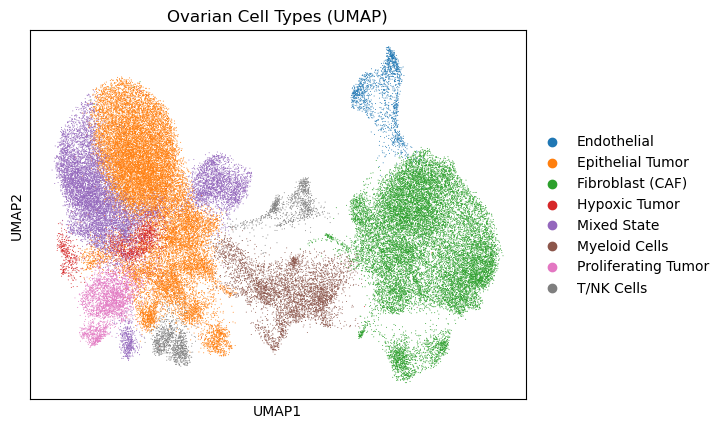

In [13]:
sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="right margin",
    title="Ovarian Cell Types (UMAP)",
    show=False
)

plt.savefig(os.path.join(BASE_PATH, "celltypes_umap.pdf"), bbox_inches="tight")
plt.show()
plt.close()

### Spatial Visualization

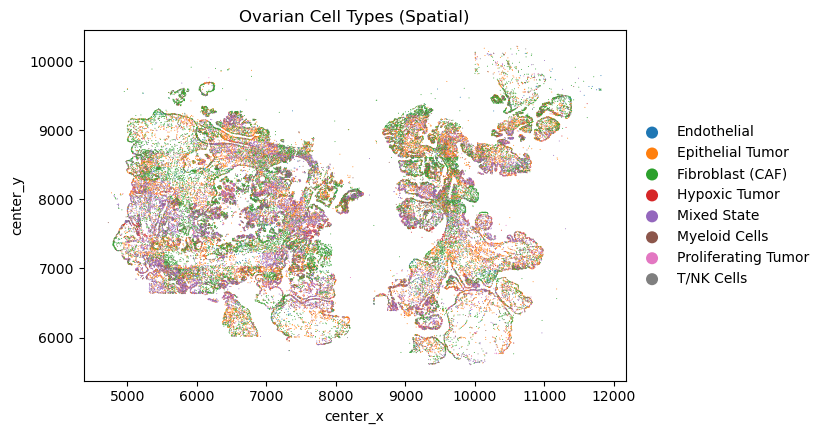

In [14]:
sc.pl.scatter(
    adata,
    x="center_x",
    y="center_y",
    color="cell_type",
    legend_loc="right margin",
    title="Ovarian Cell Types (Spatial)",
    show=False
)

plt.savefig(os.path.join(BASE_PATH, "celltypes_spatial.pdf"), bbox_inches="tight")
plt.show()
plt.close()

In [15]:
print(adata.uns["neighbors"]["params"])

{'method': 'umap', 'metric': 'euclidean', 'n_neighbors': 15, 'n_pcs': 30, 'random_state': 0}


### Modality Comparison (Spatial Plots)

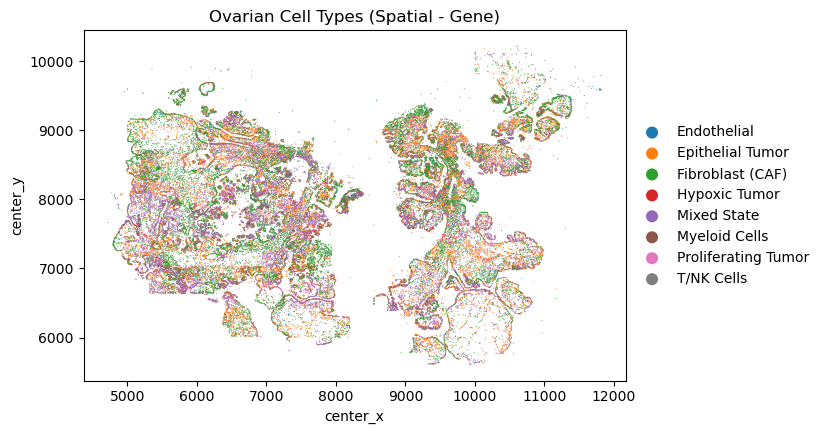

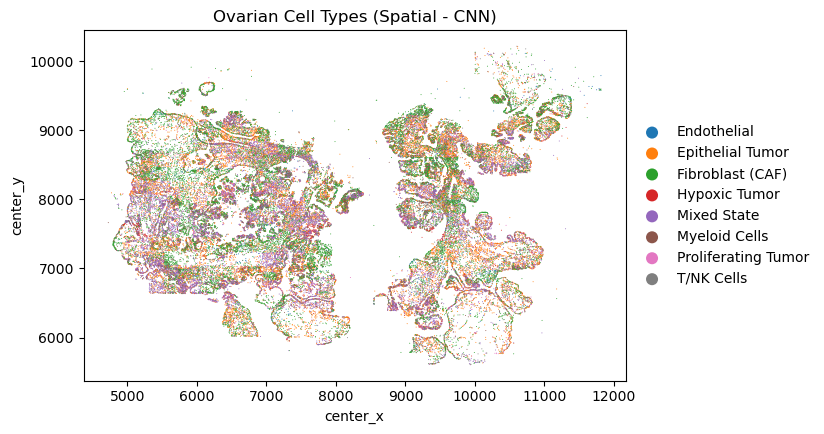

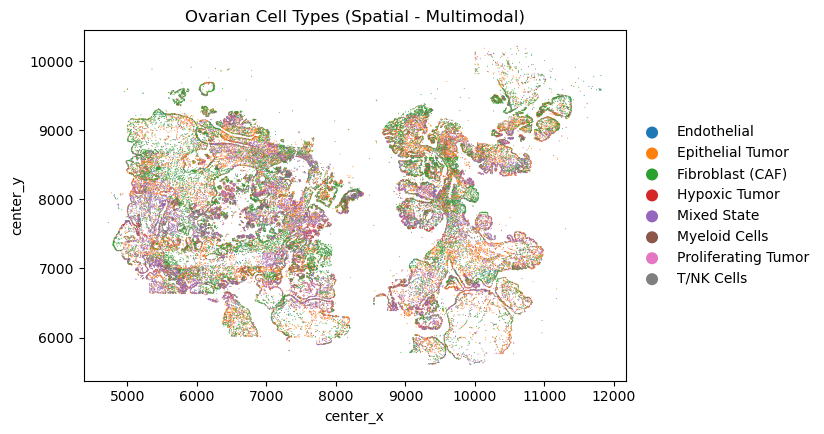

In [19]:
# import os
# import scanpy as sc
# import matplotlib.pyplot as plt

# BASE_PATH = r"C:\Users\mills\Desktop\Angione Lab\OC"

modalities = {
    "Gene": "leiden_Gene",
    "CNN": "leiden_CNN",
    "Multimodal": "leiden_Multimodal"
}

for name, cluster_col in modalities.items():

    if cluster_col not in adata.obs.columns:
        print(f"Skipping {name}: {cluster_col} not found")
        continue

    sc.pl.scatter(
        adata,
        x="center_x",
        y="center_y",
        color="cell_type",   # biological annotation
        legend_loc="right margin",
        title=f"Ovarian Cell Types (Spatial - {name})",
        show=False
    )

    plt.savefig(
        os.path.join(BASE_PATH, f"{name}_celltype_spatial.pdf"),
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

### Modality-Specific UMAPs

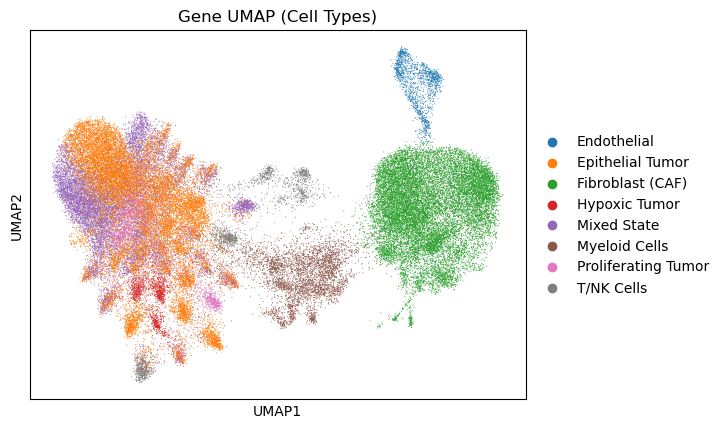

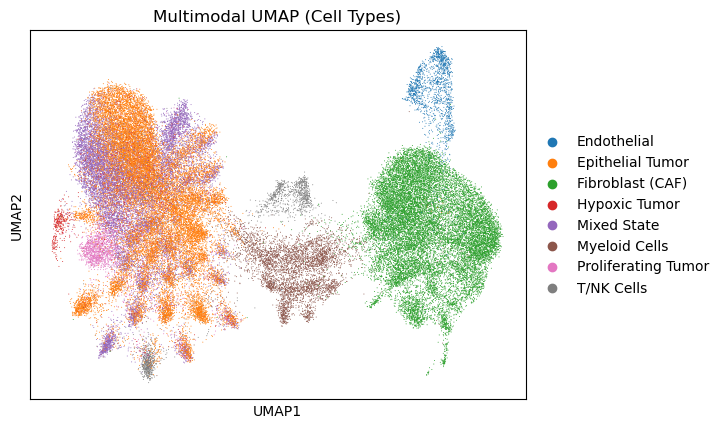

In [30]:
modalities = {
    "Gene": "X_gene",
    "Multimodal": "X_multi"
}

for name, rep in modalities.items():

    if rep not in adata.obsm:
        print(f"Skipping {name}: {rep} not found")
        continue

    # build neighbors + UMAP per modality embedding
    sc.pp.neighbors(adata, use_rep=rep)
    sc.tl.umap(adata)

    sc.pl.umap(
        adata,
        color="cell_type",
        legend_loc="right margin",
        title=f"{name} UMAP (Cell Types)",
        show=False
    )

    # plt.savefig(
    #     os.path.join(BASE_PATH, f"{name}_umap_celltypes.pdf"),
    #     bbox_inches="tight"
    # )

    plt.show()
    plt.close()

In [21]:
adata

AnnData object with n_obs × n_vars = 63072 × 150
    obs: 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'outlier', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_Gene', 'leiden_CNN', 'leiden_Multimodal', 'tmp_leiden_Gene_0', 'tmp_leiden_Gene_1', 'tmp_leiden_Gene_2', 'tmp_leiden_Gene_3', 'tmp_leiden_Gene_4', 'tmp_leiden_CNN_0', 'tmp_leiden_CNN_1', 'tmp_leiden_CNN_2', 'tmp_leiden_CNN_3', 'tmp_leiden_CNN_4', 'tmp_leiden_Multimodal_0', 'tmp_leiden_Multimodal_1', 'tmp_leiden_Multimodal_2', 'tmp_leiden_Multimodal_3', 'tmp_leiden_Multimodal_4', 'leiden_CNN_top', 'cell_type'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highl

### Manual Cluster Interpretation (Sanity Check)

In [29]:
clusters = adata.uns["rank_genes_groups"]["names"].dtype.names

for cl in clusters:
    genes = adata.uns["rank_genes_groups"]["names"][cl][:5]

    print(f"\nCluster {cl}")
    print("Top genes:", ", ".join(genes))

    # Simple interpretation logic
    genes_str = " ".join(genes).lower()

    if "epcam" in genes_str or "cdh1" in genes_str:
        print("→ Likely: Epithelial / Tumor cells")

    elif "col1a1" in genes_str or "fn1" in genes_str:
        print("→ Likely: Fibroblasts (CAF)")

    elif "cd3e" in genes_str or "gzmb" in genes_str:
        print("→ Likely: T / NK cells")

    elif "cd14" in genes_str or "c1qc" in genes_str:
        print("→ Likely: Myeloid cells")

    elif "pecam1" in genes_str or "vwf" in genes_str:
        print("→ Likely: Endothelial cells")

    else:
        print("→ Likely: Mixed / Unknown")


Cluster 0
Top genes: MUC1, SERPINA1, SOX9, EPCAM, PKM
→ Likely: Epithelial / Tumor cells

Cluster 1
Top genes: NDUFA4L2, VEGFA, CA9, MYC, MMP7
→ Likely: Mixed / Unknown

Cluster 2
Top genes: LRP1, COL1A1, ENG, LGR5, PDGFRA
→ Likely: Fibroblasts (CAF)

Cluster 3
Top genes: FN1, SFRP2, COL1A1, COL5A1, PDGFRA
→ Likely: Fibroblasts (CAF)

Cluster 4
Top genes: C1QC, CD14, CSF1R, CYBB, ITGB2
→ Likely: Myeloid cells

Cluster 5
Top genes: LRP1, COL1A1, ENG, PDGFRA, LGR5
→ Likely: Fibroblasts (CAF)

Cluster 6
Top genes: MKI67, AURKB, MMP7, PKM, EPCAM
→ Likely: Epithelial / Tumor cells

Cluster 7
Top genes: CDKN1A, LAMC2, ATF3, SERPINA1, CDH1
→ Likely: Epithelial / Tumor cells

Cluster 8
Top genes: MUC1, PKM, SOX9, LGR6, MYC
→ Likely: Mixed / Unknown

Cluster 9
Top genes: TP63, LGR6, SOX9, MUC1, PKM
→ Likely: Mixed / Unknown

Cluster 10
Top genes: LAMC2, CTSG, VEGFA, LAMB3, CDH1
→ Likely: Epithelial / Tumor cells

Cluster 11
Top genes: CD207, FCER1A, PKM, MUC1, SERPINA1
→ Likely: Mixed / Unknow

### Heatmap of Marker Genes

Total genes used for heatmap: 55


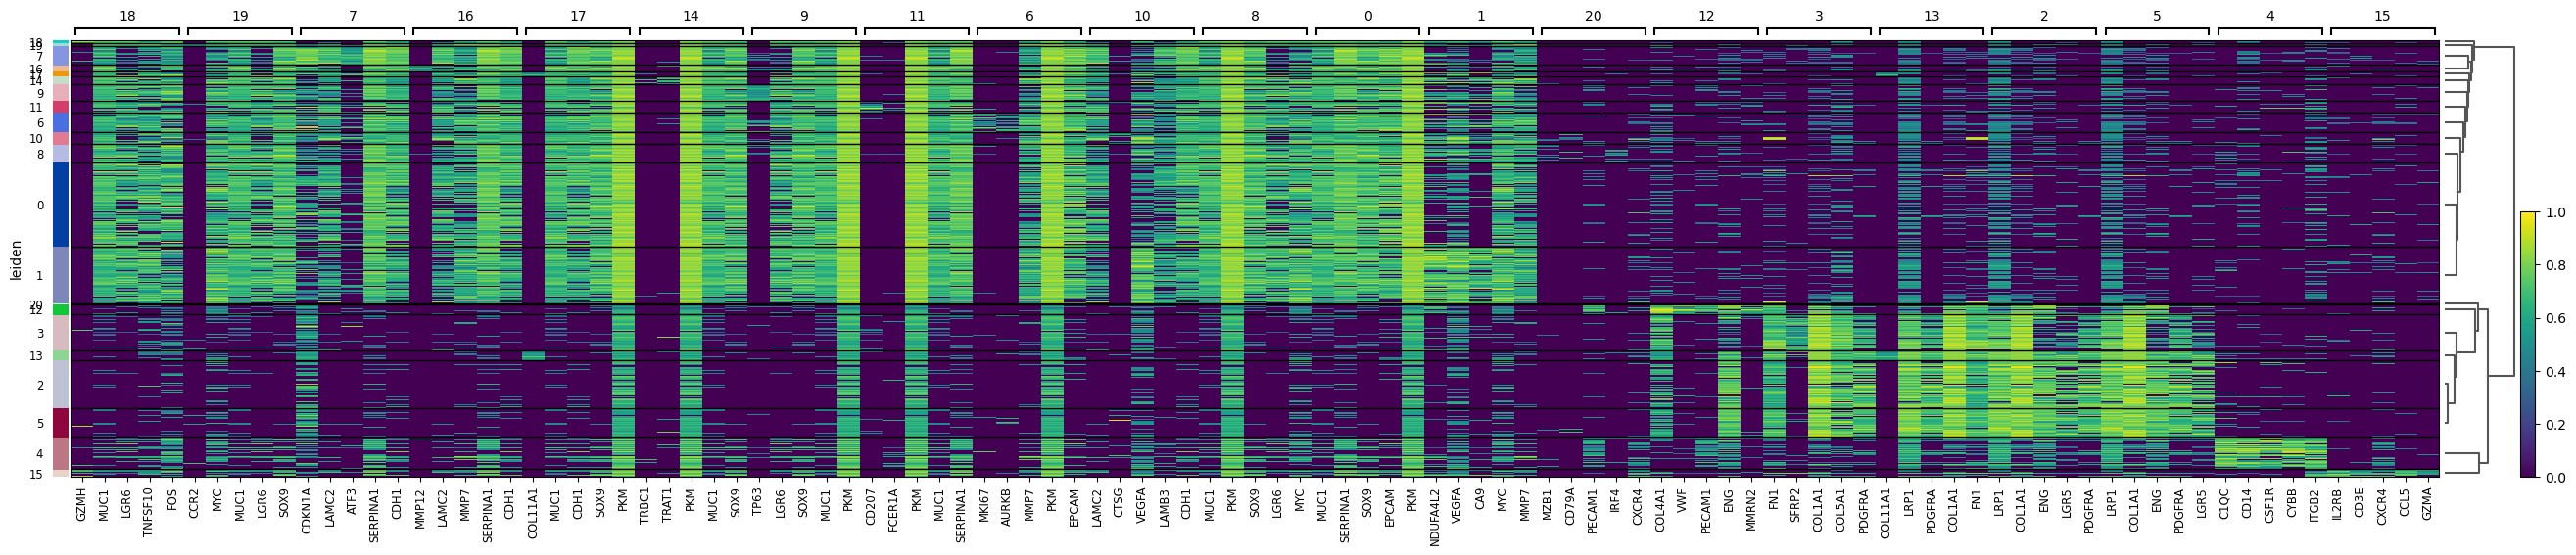

In [31]:
# Get top 5 genes per cluster

clusters = adata.uns["rank_genes_groups"]["names"].dtype.names

top_genes = []

for cl in clusters:
    genes = adata.uns["rank_genes_groups"]["names"][cl][:5]
    top_genes.extend(genes)

# remove duplicates while preserving order
top_genes = list(dict.fromkeys(top_genes))

print("Total genes used for heatmap:", len(top_genes))

sc.pl.rank_genes_groups_heatmap(
    adata,
    groups=clusters,
    n_genes=5,
    standard_scale="var",   # important for comparability
    show_gene_labels=True,
    cmap="viridis",
    dendrogram=True
)

### Refined Heatmap Visualization

In [32]:
clusters = adata.uns["rank_genes_groups"]["names"].dtype.names

top_genes = []

# take ONLY top 3 genes per cluster (clean figure)
for cl in clusters:
    genes = adata.uns["rank_genes_groups"]["names"][cl][:3]
    top_genes.extend(genes)

# remove duplicates
top_genes = list(dict.fromkeys(top_genes))

print("Genes used:", len(top_genes))

Genes used: 43


In [33]:
sc.tl.dendrogram(adata, groupby="leiden")

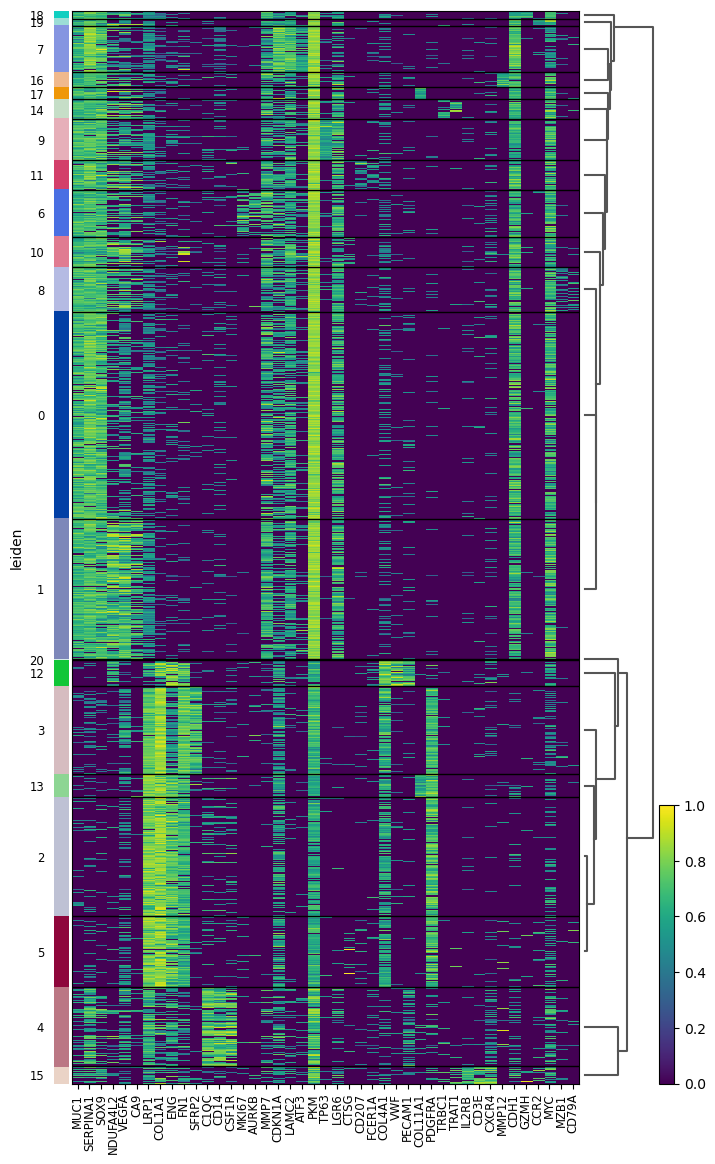

In [41]:
sc.pl.heatmap(
    adata,
    var_names=top_genes,
    groupby="leiden",
    standard_scale="var",
    cmap="viridis",
    dendrogram=True,
    figsize=(8, 14)  
)